# Actividad 3.2 - Valores Atípicos

En esta actividad se aplicarán los métodos de Desviación Estándar y Rango Intercuartílico (IQR) para identificar valores atípicos en la base de datos.

También se utilizarán diagramas de caja para comprobar visualmente la presencia de valores atípicos.

In [1]:
# Importamos las librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
# Cargamos la base de datos
data = pd.read_csv('Base_de_Tlaxcala_Sin_Nulos.csv')


In [5]:
# Revisamos cuántas filas y columnas contiene nuestra base

data.shape

(56, 12)

In [6]:
# Revisamos la información general de nuestra base

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Fecha de Alta  56 non-null     str  
 1   Mes Lead       56 non-null     int64
 2   AgLead         56 non-null     str  
 3   Titulo         56 non-null     str  
 4   Nombre         56 non-null     str  
 5   Producto       56 non-null     str  
 6   Temperatura    56 non-null     str  
 7   Comentario     56 non-null     str  
 8   Asesor         56 non-null     str  
 9   Fuente         56 non-null     str  
 10  Origen         56 non-null     str  
 11  Estatus        56 non-null     str  
dtypes: int64(1), str(11)
memory usage: 5.4 KB


In [7]:
# Revisamos si existen valores nulos

valores_nulos = data.isnull().sum()

valores_nulos

Fecha de Alta    0
Mes Lead         0
AgLead           0
Titulo           0
Nombre           0
Producto         0
Temperatura      0
Comentario       0
Asesor           0
Fuente           0
Origen           0
Estatus          0
dtype: int64

In [8]:
# Identificamos las variables numéricas

columnas_numericas = data.select_dtypes(include=np.number).columns.tolist()

columnas_numericas

['Mes Lead']

In [9]:
# Revisamos los valores que contiene Mes Lead

data['Mes Lead'].value_counts()

Mes Lead
10    56
Name: count, dtype: int64

In [10]:
# Seleccionamos la variable numérica para el análisis de valores atípicos

columnas_cuantitativas = ['Mes Lead']

cuantitativas = data[columnas_cuantitativas]

cuantitativas.head()

,Mes Lead
0,10
1,10
2,10
3,10
4,10


In [11]:
# Guardamos las demás variables por separado

cualitativas = data.drop(columns=columnas_cuantitativas)

cualitativas.head()

,Fecha de Alta,AgLead,Titulo,Nombre,Producto,Temperatura,Comentario,Asesor,Fuente,Origen,Estatus
0,2025-10-30,560dd80fc9a1878495e1af33f7b4bd95,Lead GALERIAS TLAXCALA,Jose Juan Felipe Arenas Huerta,EMZOOM,Lead Interes Bajo,Cita en Custom-Prueba de manejoFinal:EMZOOM,Antonio Licona,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Contactado
1,2025-10-28,98a6be793540ff2fd5d29f4c4d1db313,Lead GALERIAS TLAXCALA,Guillermo Ortiz Lopez,EMZOOM,Lead Interes Medio,quiere cotizaciÃ³n de arrendamiento y financia...,Alvaro Celso Mora Rosete,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Contactado
2,2025-10-27,6704bccc5cddec9bc40d0cc1962b13c9,Lead GALERIAS TLAXCALA,Mireya De Lucio,EMZOOM,Lead Interes Medio,mandar cotizacioneaPidieron:GS4 MAX GL,JULIO CESAR GARCIA GARCIA,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Contactado
3,2025-10-27,1c4b5a464d33036f8f3848eba6b4946f,Lead GALERIAS TLAXCALA,Francisco Javier Flores Caldera,EMZOOM,Lead Interes Medio,quiere que le mande ficha tÃ©cnica catÃ¡logo y...,Alvaro Celso Mora Rosete,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Contactado
4,2025-10-23,7cf8d8cb36bef73fd710a82e0e585a1c,Lead GALERIAS TLAXCALA,Sarahi Mendieta,EMZOOM,Lead Interes Medio,Se programa para el sabado una prueba de manej...,Antonio Licona,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Finalizado


/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_96684/1333506928.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


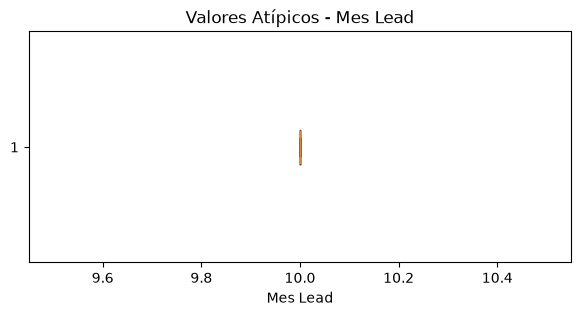

In [12]:
# Creamos el diagrama de caja antes de aplicar los métodos

plt.figure(figsize=(7,3))

plt.boxplot(
    cuantitativas['Mes Lead'].dropna(),
    vert=False
)

plt.title("Valores Atípicos - Mes Lead")

plt.xlabel("Mes Lead")

plt.show()

# Método 1: Desviación Estándar

Este método permite identificar valores que se encuentren demasiado alejados del promedio de los datos.

Se utilizará la media ± 3 desviaciones estándar para establecer los límites permitidos.

In [13]:
# Calculamos la media de Mes Lead

media = cuantitativas.mean()

media

Mes Lead    10.0
dtype: float64

In [14]:
# Calculamos la desviación estándar

desviacion = cuantitativas.std()

desviacion

Mes Lead    0.0
dtype: float64

In [15]:
# Calculamos los límites utilizando
# media ± 3 desviaciones estándar

y = cuantitativas

Limite_Superior = y.mean() + 3 * y.std()

Limite_Inferior = y.mean() - 3 * y.std()

In [16]:
print("Límite Superior:")
print(Limite_Superior)

print("\nLímite Inferior:")
print(Limite_Inferior)

Límite Superior:
Mes Lead    10.0
dtype: float64

Límite Inferior:
Mes Lead    10.0
dtype: float64


In [17]:
# Identificamos los valores que se encuentren
# dentro de los límites permitidos

data_std = cuantitativas[
    (y <= Limite_Superior) &
    (y >= Limite_Inferior)
]

data_std

,Mes Lead
0,10
1,10
2,10
3,10
4,10
5,10
6,10
7,10
8,10
9,10


In [18]:
# Contamos los valores atípicos encontrados

outliers_desviacion = data_std.isnull().sum()

print("Valores atípicos encontrados:")

outliers_desviacion

Valores atípicos encontrados:


Mes Lead    0
dtype: int64

In [19]:
# Creamos una copia de los datos

data_clean_std = data_std.copy()

In [20]:
# En caso de existir valores atípicos,
# serían sustituidos utilizando la media

data_clean_std = data_clean_std.fillna(
    round(data_std.mean(), 1)
)

data_clean_std

,Mes Lead
0,10
1,10
2,10
3,10
4,10
5,10
6,10
7,10
8,10
9,10


In [21]:
# Unimos nuevamente las variables

Datos_limpios_std = pd.concat(
    [cualitativas, data_clean_std],
    axis=1
)

In [22]:
# Recuperamos el orden original de las columnas

Datos_limpios_std = Datos_limpios_std[data.columns]

Datos_limpios_std.head()

,Fecha de Alta,Mes Lead,AgLead,Titulo,Nombre,Producto,Temperatura,Comentario,Asesor,Fuente,Origen,Estatus
0,2025-10-30,10,560dd80fc9a1878495e1af33f7b4bd95,Lead GALERIAS TLAXCALA,Jose Juan Felipe Arenas Huerta,EMZOOM,Lead Interes Bajo,Cita en Custom-Prueba de manejoFinal:EMZOOM,Antonio Licona,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Contactado
1,2025-10-28,10,98a6be793540ff2fd5d29f4c4d1db313,Lead GALERIAS TLAXCALA,Guillermo Ortiz Lopez,EMZOOM,Lead Interes Medio,quiere cotizaciÃ³n de arrendamiento y financia...,Alvaro Celso Mora Rosete,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Contactado
2,2025-10-27,10,6704bccc5cddec9bc40d0cc1962b13c9,Lead GALERIAS TLAXCALA,Mireya De Lucio,EMZOOM,Lead Interes Medio,mandar cotizacioneaPidieron:GS4 MAX GL,JULIO CESAR GARCIA GARCIA,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Contactado
3,2025-10-27,10,1c4b5a464d33036f8f3848eba6b4946f,Lead GALERIAS TLAXCALA,Francisco Javier Flores Caldera,EMZOOM,Lead Interes Medio,quiere que le mande ficha tÃ©cnica catÃ¡logo y...,Alvaro Celso Mora Rosete,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Contactado
4,2025-10-23,10,7cf8d8cb36bef73fd710a82e0e585a1c,Lead GALERIAS TLAXCALA,Sarahi Mendieta,EMZOOM,Lead Interes Medio,Se programa para el sabado una prueba de manej...,Antonio Licona,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Finalizado


/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_96684/739755377.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


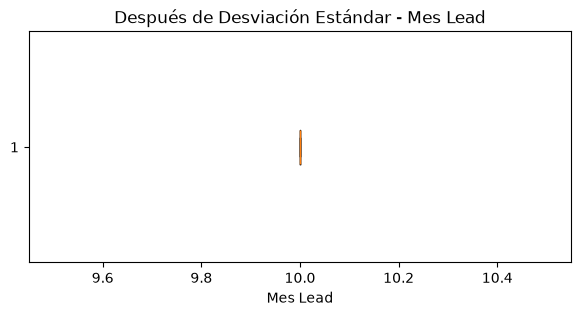

In [23]:
# Diagrama de caja después de aplicar
# Desviación Estándar

plt.figure(figsize=(7,3))

plt.boxplot(
    Datos_limpios_std['Mes Lead'].dropna(),
    vert=False
)

plt.title("Después de Desviación Estándar - Mes Lead")

plt.xlabel("Mes Lead")

plt.show()

In [24]:
# Guardamos el resultado en un archivo CSV

Datos_limpios_std.to_csv(
    "Datos_Desviacion_Estandar.csv",
    index=False
)

# Método 2: Rango Intercuartílico (IQR)

Este método utiliza el primer cuartil (Q1) y el tercer cuartil (Q3) para establecer los límites de los datos.

Los valores que se encuentren fuera de dichos límites son considerados valores atípicos.

In [25]:
# Calculamos el primer y tercer cuartil

y = cuantitativas

percentile25 = y.quantile(0.25)

percentile75 = y.quantile(0.75)

print("Q1:")
print(percentile25)

print("\nQ3:")
print(percentile75)

Q1:
Mes Lead    10.0
Name: 0.25, dtype: float64

Q3:
Mes Lead    10.0
Name: 0.75, dtype: float64


In [26]:
# Calculamos el Rango Intercuartílico

iqr = percentile75 - percentile25

iqr

Mes Lead    0.0
dtype: float64

In [27]:
# Calculamos los límites del método IQR

Limite_Superior_iqr = percentile75 + 1.5 * iqr

Limite_Inferior_iqr = percentile25 - 1.5 * iqr

In [28]:
print("Límite Superior:")
print(Limite_Superior_iqr)

print("\nLímite Inferior:")
print(Limite_Inferior_iqr)

Límite Superior:
Mes Lead    10.0
dtype: float64

Límite Inferior:
Mes Lead    10.0
dtype: float64


In [29]:
# Identificamos los valores que se encuentran
# dentro de los límites permitidos

data_iqr = cuantitativas[
    (y <= Limite_Superior_iqr) &
    (y >= Limite_Inferior_iqr)
]

data_iqr

,Mes Lead
0,10
1,10
2,10
3,10
4,10
5,10
6,10
7,10
8,10
9,10


In [30]:
# Contamos los valores atípicos encontrados

outliers_iqr = data_iqr.isnull().sum()

print("Valores atípicos encontrados mediante IQR:")

outliers_iqr

Valores atípicos encontrados mediante IQR:


Mes Lead    0
dtype: int64

In [31]:
# Creamos una copia

data_clean_iqr = data_iqr.copy()

In [32]:
# En caso de existir valores atípicos,
# serían sustituidos utilizando la mediana

data_clean_iqr = data_clean_iqr.fillna(
    round(data_iqr.median(), 1)
)

data_clean_iqr

,Mes Lead
0,10
1,10
2,10
3,10
4,10
5,10
6,10
7,10
8,10
9,10


In [33]:
# Unimos nuevamente las variables

Datos_limpios_iqr = pd.concat(
    [cualitativas, data_clean_iqr],
    axis=1
)

In [34]:
# Recuperamos el orden original

Datos_limpios_iqr = Datos_limpios_iqr[data.columns]

Datos_limpios_iqr.head()

,Fecha de Alta,Mes Lead,AgLead,Titulo,Nombre,Producto,Temperatura,Comentario,Asesor,Fuente,Origen,Estatus
0,2025-10-30,10,560dd80fc9a1878495e1af33f7b4bd95,Lead GALERIAS TLAXCALA,Jose Juan Felipe Arenas Huerta,EMZOOM,Lead Interes Bajo,Cita en Custom-Prueba de manejoFinal:EMZOOM,Antonio Licona,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Contactado
1,2025-10-28,10,98a6be793540ff2fd5d29f4c4d1db313,Lead GALERIAS TLAXCALA,Guillermo Ortiz Lopez,EMZOOM,Lead Interes Medio,quiere cotizaciÃ³n de arrendamiento y financia...,Alvaro Celso Mora Rosete,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Contactado
2,2025-10-27,10,6704bccc5cddec9bc40d0cc1962b13c9,Lead GALERIAS TLAXCALA,Mireya De Lucio,EMZOOM,Lead Interes Medio,mandar cotizacioneaPidieron:GS4 MAX GL,JULIO CESAR GARCIA GARCIA,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Contactado
3,2025-10-27,10,1c4b5a464d33036f8f3848eba6b4946f,Lead GALERIAS TLAXCALA,Francisco Javier Flores Caldera,EMZOOM,Lead Interes Medio,quiere que le mande ficha tÃ©cnica catÃ¡logo y...,Alvaro Celso Mora Rosete,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Contactado
4,2025-10-23,10,7cf8d8cb36bef73fd710a82e0e585a1c,Lead GALERIAS TLAXCALA,Sarahi Mendieta,EMZOOM,Lead Interes Medio,Se programa para el sabado una prueba de manej...,Antonio Licona,11.Origen Personalizado/Calle,GALERIAS TLAXCALA,Finalizado


/var/folders/30/hd8bglwn1xd480qb298v6r_w0000gn/T/ipykernel_96684/1515516942.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


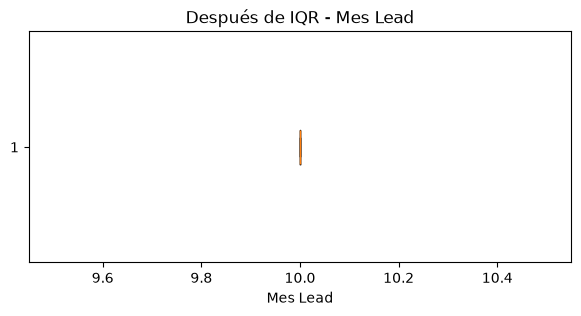

In [35]:
# Diagrama de caja después de aplicar IQR

plt.figure(figsize=(7,3))

plt.boxplot(
    Datos_limpios_iqr['Mes Lead'].dropna(),
    vert=False
)

plt.title("Después de IQR - Mes Lead")

plt.xlabel("Mes Lead")

plt.show()

In [36]:
# Guardamos el resultado del método IQR

Datos_limpios_iqr.to_csv(
    "Datos_IQR.csv",
    index=False
)

## Conclusión

En esta base de datos se identificó únicamente una variable numérica llamada Mes Lead.

Al aplicar el método de Desviación Estándar no se encontraron valores atípicos, debido a que los 56 registros contienen el mismo valor, correspondiente al mes 10.

Posteriormente se aplicó el método de Rango Intercuartílico (IQR), obteniendo nuevamente 0 valores atípicos.

Los diagramas de caja confirmaron estos resultados, ya que todos los datos se encuentran concentrados en el mismo valor.

Por lo tanto, no fue necesario modificar o eliminar ningún registro de la variable analizada.